In [ ]:
# imported packages
import emcee
import h5py
import numpy as np
import os
from pathlib import Path
from scipy.special import lambertw
from numpy.random import default_rng
from scipy import linalg
from scipy.signal import argrelextrema
from scipy.linalg import sqrtm
#import from my scripts
import pp_model.PPmodel as pp

In [ ]:
fold_num = 1
file_num = 28
file_num_str = str(file_num).zfill(2)

# Set tile width you want to use
tile_width = 8

# Set experiment type 
exp_num = '_exp01'

# path to LES files
LES_path = 'LES/'

#load mean cycle
noisy_lc = np.loadtxt((LES_path + 'mean/%d_' + file_num_str + '_infall.txt') %fold_num , delimiter = ',')

#smaller number of data 
#makes matrix to account for the fact that the data are sampled every 2 minutes and 
#the MCMC samples every 0.1 minutes
ny = len(noisy_lc)
nx = (len(noisy_lc) - 1)*20 + 1
spacing = 20
H = np.zeros((ny, nx))
print(H.shape)
for i in range(0, ny): 
    H[i, i*spacing] = 1

    #load covariance matrix
R = np.loadtxt((LES_path + 'cov/%d_' + file_num_str + '_infall.txt') %fold_num, delimiter = ',')

#Calculating R_sqrt using SVD
[u,l,q] = np.linalg.svd(R)
R_sqrt = u@(np.identity(len(noisy_lc))*np.sqrt(l))

In [ ]:
#number of walkers for the ensemble
nwalkers = 20
#dimensions of the parameter space
ndim = 4
#locate data cycle extrema
noisy_extrem = (np.argmax(noisy_lc))*20 

#load prior samples
my_samples = np.loadtxt('pp_model/files/prior/prior_samples'+exp_num+'.txt', delimiter = ',')
# my_samples[:,3] = my_samples[:,3]**2

#Pick 1000 random samples and find the nwalkers that give the highest probability values
my_random_samples = np.random.randint(0, len(my_samples), 5000)

my_log_probs = np.zeros(len(my_random_samples))
for tt in range(0, len(my_log_probs)): 
    testing = my_samples[my_random_samples[tt]]
    my_log_probs[tt] =pp.log_post(testing, noisy_lc, noisy_extrem, nx, u, l, H)


x_samples = my_samples[my_random_samples[np.argsort(my_log_probs)[-nwalkers:]]]
print(my_log_probs[np.argsort(my_log_probs)[-nwalkers:]])

[-12.91829694 -12.4473804  -12.4064236  -11.40369281 -11.09402117
 -10.86740566 -10.78872079 -10.36916777  -9.62067737  -9.34620794
  -9.08006288  -9.03980674  -8.88196068  -8.63910785  -7.5541012
  -7.04973523  -4.84210078  -4.13818573  -4.06672715  -2.08658914]


In [ ]:
# Set up the backend
# Don't forget to clear it in case the file already exists
filename = ('pp_model/files/mcmc_runs/test.h5')
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)

#Running the MC Hamer sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, pp.log_post, 
                                args = [noisy_lc, noisy_extrem, nx, u, l, H],  backend=backend)

sampler.run_mcmc(x_samples, 500) #10^5

print('In the prior?', bool(pp.prior(sampler.get_chain()[-1,4])))

In the prior? True


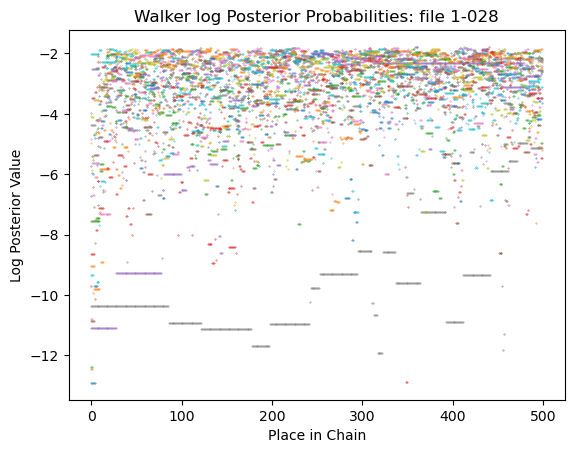

In [9]:
#Plot chains
import matplotlib.pyplot as plt
log_probs = sampler.get_log_prob()
plt.figure()
plt.title(('Walker log Posterior Probabilities: file %d-0' + file_num_str)%fold_num)
plt.xlabel('Place in Chain')
plt.ylabel('Log Posterior Value')
for i in range(0, 20): 
    plt.scatter(np.arange(0, len(log_probs)),
                log_probs[0:,i], s = 0.1)
plt.show(block = True)